In [1]:
import pandas as pd
import os

# Load both CSV files
df1 = pd.read_csv("dresses_bd_processed_data.csv")
df2 = pd.read_csv("jeans_bd_processed_data.csv")

# Merge them row-wise (assuming same columns)
df_merged = pd.concat([df1, df2], ignore_index=True)

# Optional: Drop duplicate rows based on product_id or other unique identifier
# df_merged = df_merged.drop_duplicates(subset='product_id')

# Optional: Reset index
df_merged.reset_index(drop=True, inplace=True)

# Create output directory if needed
os.makedirs("data/processed", exist_ok=True)

# Save to new CSV
df_merged.to_csv("data/processed/fashion_dataset.csv", index=False)

print("Merged dataset saved as 'data/processed/fashion_dataset.csv'")


✅ Merged dataset saved as 'data/processed/fashion_dataset.csv'


In [3]:
!pip install matplotlib

     ---------------------------------------- 8.1/8.1 MB 6.0 MB/s eta 0:00:00
     -------------------------------------- 222.0/222.0 kB 4.5 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
     ---------------------------------------- 2.2/2.2 MB 5.7 MB/s eta 0:00:00
     ---------------------------------------- 72.0/72.0 kB 3.9 MB/s eta 0:00:00
     -------------------------------------- 111.1/111.1 kB 6.3 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: C:\Users\karishma\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [5]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: C:\Users\karishma\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [6]:
#  1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Plot aesthetics
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

#  2. Load the dataset
df = pd.read_csv("data/processed/fashion_dataset.csv")

# 3. Clean price & MRP columns (if they're JSON strings like {'INR': 1234.56})
def extract_inr(val):
    try:
        return float(ast.literal_eval(val).get("INR", 0))
    except:
        return 0.0
df["selling_price"] = df["selling_price"].apply(extract_inr)
df["mrp"] = df["mrp"].apply(extract_inr)

In [8]:
print(df.columns)


Index(['selling_price', 'discount', 'category_id', 'meta_info', 'product_id',
       'pdp_url', 'sku', 'brand', 'department_id', 'last_seen_date',
       'launch_on', 'mrp', 'product_name', 'feature_image_s3', 'channel_id',
       'feature_list', 'description', 'style_attributes', 'pdp_images_s3'],
      dtype='object')


C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\2084045923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.values, y=top_brands.index, palette="magma")


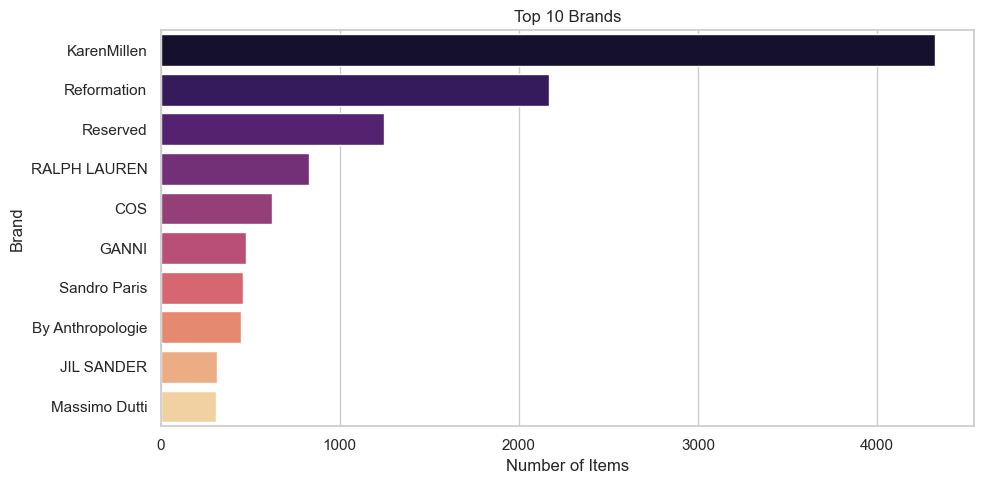

In [12]:
# 5. Top Brands
top_brands = df["brand"].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.values, y=top_brands.index, palette="magma")
plt.title("Top 10 Brands")
plt.xlabel("Number of Items")
plt.ylabel("Brand")
plt.tight_layout()
plt.show()

In [ ]:


# Load your fashion dataset
df = pd.read_csv("data/processed/fashion_dataset.csv")

# Set the plot style
sns.set(style="whitegrid")

# Count top 10 categories
top_categories = df['category_id'].value_counts().head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette="coolwarm")
plt.title("🔝 Top 10 Fashion Categories", fontsize=16)
plt.xlabel("Number of Items")
plt.ylabel("Category")
plt.tight_layout()

# Save to file
plt.savefig("images/top_categories.png", bbox_inches='tight')
plt.show()


C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\2687544645.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette="coolwarm")
C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\2687544645.py:16: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\2687544645.py:19: UserWarning: Glyph 128285 (\N{TOP WITH UPWARDS ARROW ABOVE}) missing from font(s) Arial.
  plt.savefig("images/top_categories.png", bbox_inches='tight')


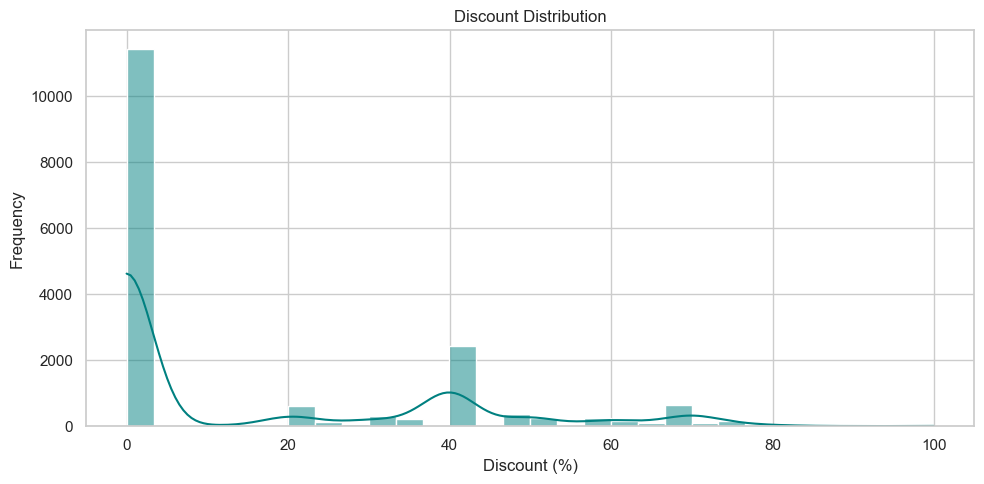

In [13]:
#  6. Discount Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df["discount"], bins=30, kde=True, color="teal")
plt.title("Discount Distribution")
plt.xlabel("Discount (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

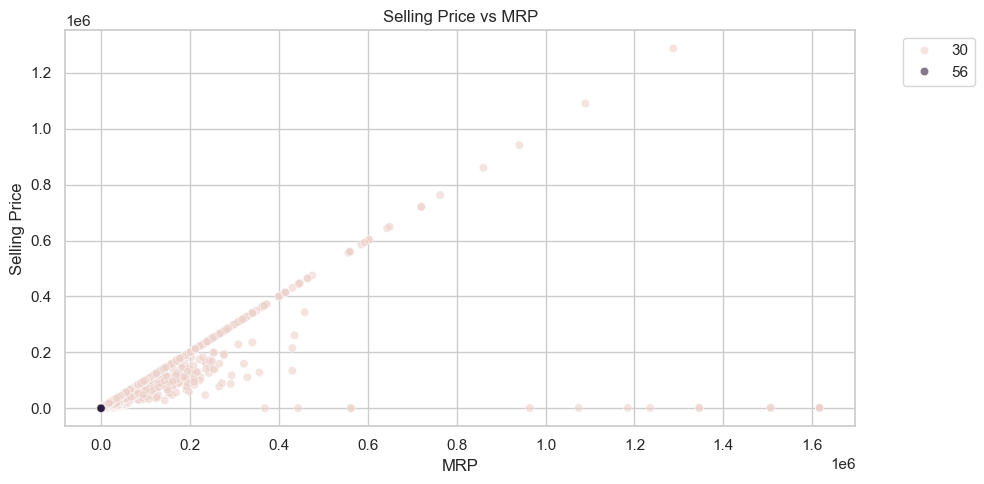

In [15]:
#  7. Selling Price vs MRP
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="mrp", y="selling_price", hue="category_id", alpha=0.6)
plt.title("Selling Price vs MRP")
plt.xlabel("MRP")
plt.ylabel("Selling Price")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\3797778512.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, palette="coolwarm")


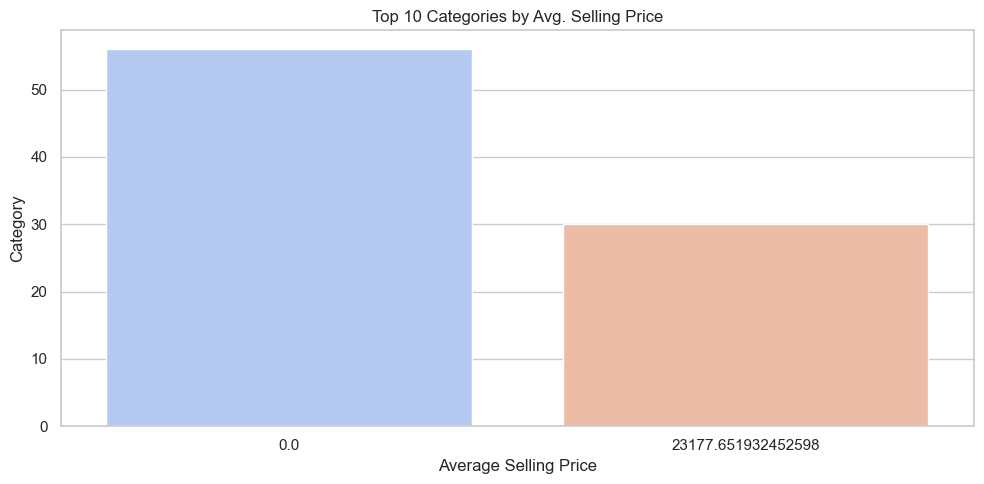

In [17]:
#  8. Average Selling Price per Category
avg_price = df.groupby("category_id")["selling_price"].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price.values, y=avg_price.index, palette="coolwarm")
plt.title("Top 10 Categories by Avg. Selling Price")
plt.xlabel("Average Selling Price")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [19]:
!pip install wordcloud

     -------------------------------------- 299.9/299.9 kB 4.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 25.1.1
[notice] To update, run: C:\Users\karishma\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


C:\Users\karishma\AppData\Local\Temp\ipykernel_20836\3563726880.py:23: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\karishma\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


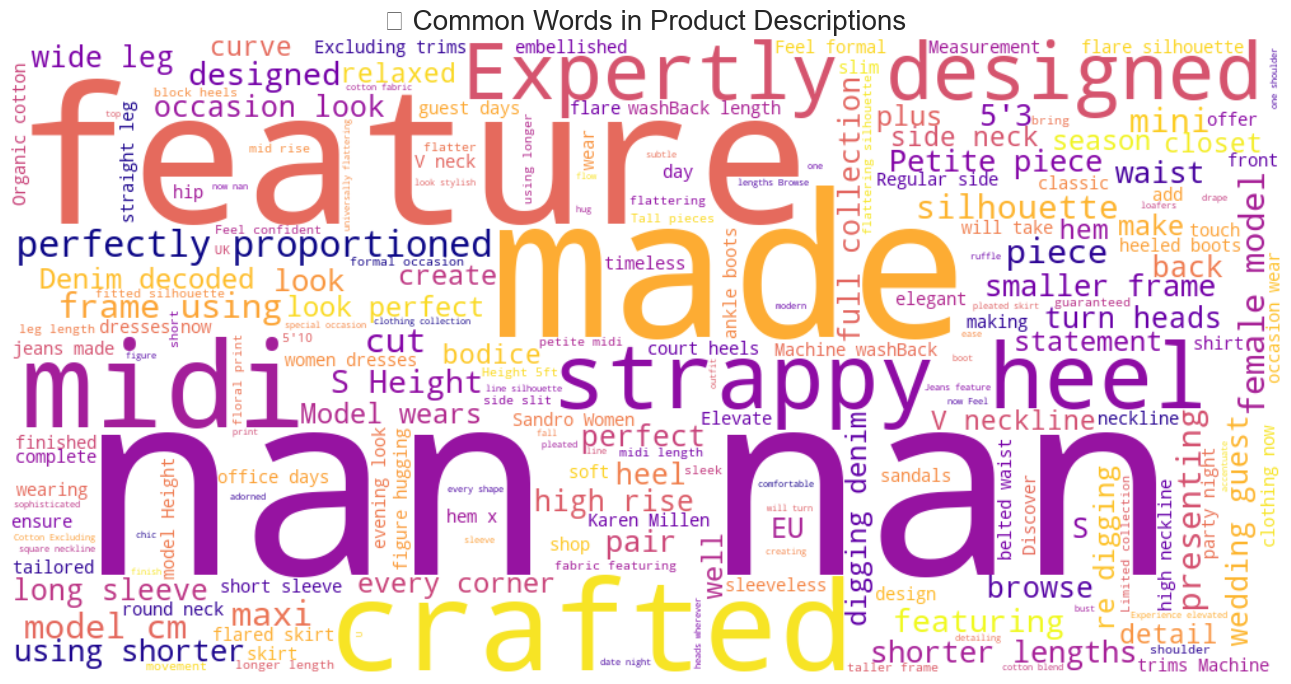

In [20]:
#  9. Word Cloud of Product Descriptions
from wordcloud import WordCloud, STOPWORDS

# Combine all descriptions
text = " ".join(desc for desc in df["description"].astype(str) if pd.notnull(desc))

# Optional: add stopwords
stopwords = set(STOPWORDS)
stopwords.update(["fit", "size", "dress", "style", "product"])

# Generate word cloud
wordcloud = WordCloud(width=1000, height=500,
                      background_color="white",
                      stopwords=stopwords,
                      colormap="plasma",
                      max_words=200).generate(text)

# Plot
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("🧠 Common Words in Product Descriptions", fontsize=20)
plt.tight_layout()
plt.show()
